In [32]:
import math
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [33]:
# ==========================================================
# 1. KONFIGURASI SISTEM & GENERASI DATA
# ==========================================================
random.seed(42)
np.random.seed(42)

NUM_HOUSES = 100
GRID_SIZE = 30 
NUM_TPS = 3
NUM_GARTS = 7  
NUM_TRUCKS = 4 

TIME_GAR_START = 6 * 60  
TIME_GAR_END = 15 * 60    
TIME_TRK_START = 8 * 60  
TIME_TRK_END = 17 * 60    

class Entity:
    def __init__(self, id_ent, x, y):
        self.id = id_ent
        self.x = x
        self.y = y

class House(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.waste = random.uniform(0.1, 7.0)

class TPS(Entity):
    def __init__(self, id_ent, x, y):
        super().__init__(id_ent, x, y)
        self.cap = 500.0
        self.load = 0.0

class Vehicle(Entity):
    def __init__(self, id_ent, vtype, cap, start_t, end_t, speed_min_per_dist, load_min_per_kg, home_tps):
        super().__init__(id_ent, home_tps.x, home_tps.y) # Memulai posisi dari TPS tempat bernaung
        self.vtype = vtype
        self.cap = cap
        self.load = 0
        self.t = start_t
        self.start_t = start_t
        self.end_t = end_t
        self.speed = speed_min_per_dist
        self.load_time = load_min_per_kg
        self.dist_traveled = 0
        self.log = []
        self.home_tps = home_tps # Menyimpan referensi TPS markas

def get_dist(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)

# --- Inisialisasi Objek & Distribusi Agen ke TPS ---
houses = [House(f"H{i+1}", random.uniform(0, GRID_SIZE), random.uniform(0, GRID_SIZE)) for i in range(NUM_HOUSES)]
tps_coords = [(5, 5), (GRID_SIZE-5, GRID_SIZE-5), (GRID_SIZE/2, GRID_SIZE-5)]
tps_list = [TPS(f"TPS-{i+1}", tps_coords[i][0], tps_coords[i][1]) for i in range(NUM_TPS)]
truck_dist = [2, 1, 1]
gart_dist = [3, 2, 2]

trucks = []
t_idx = 1
for i, count in enumerate(truck_dist):
    for _ in range(count):
        trucks.append(Vehicle(f"Truk-{t_idx}", "Truk", 200, TIME_TRK_START, TIME_TRK_END, 3.0/5.0, 2.0/10.0, tps_list[i]))
        t_idx += 1

carts = []
c_idx = 1
for i, count in enumerate(gart_dist):
    for _ in range(count):
        carts.append(Vehicle(f"Gerobak-{c_idx}", "Gerobak", 15, TIME_GAR_START, TIME_GAR_END, 3.0, 2.0, tps_list[i]))
        c_idx += 1

all_vehicles = carts + trucks

Membuat peta interkoneksi...


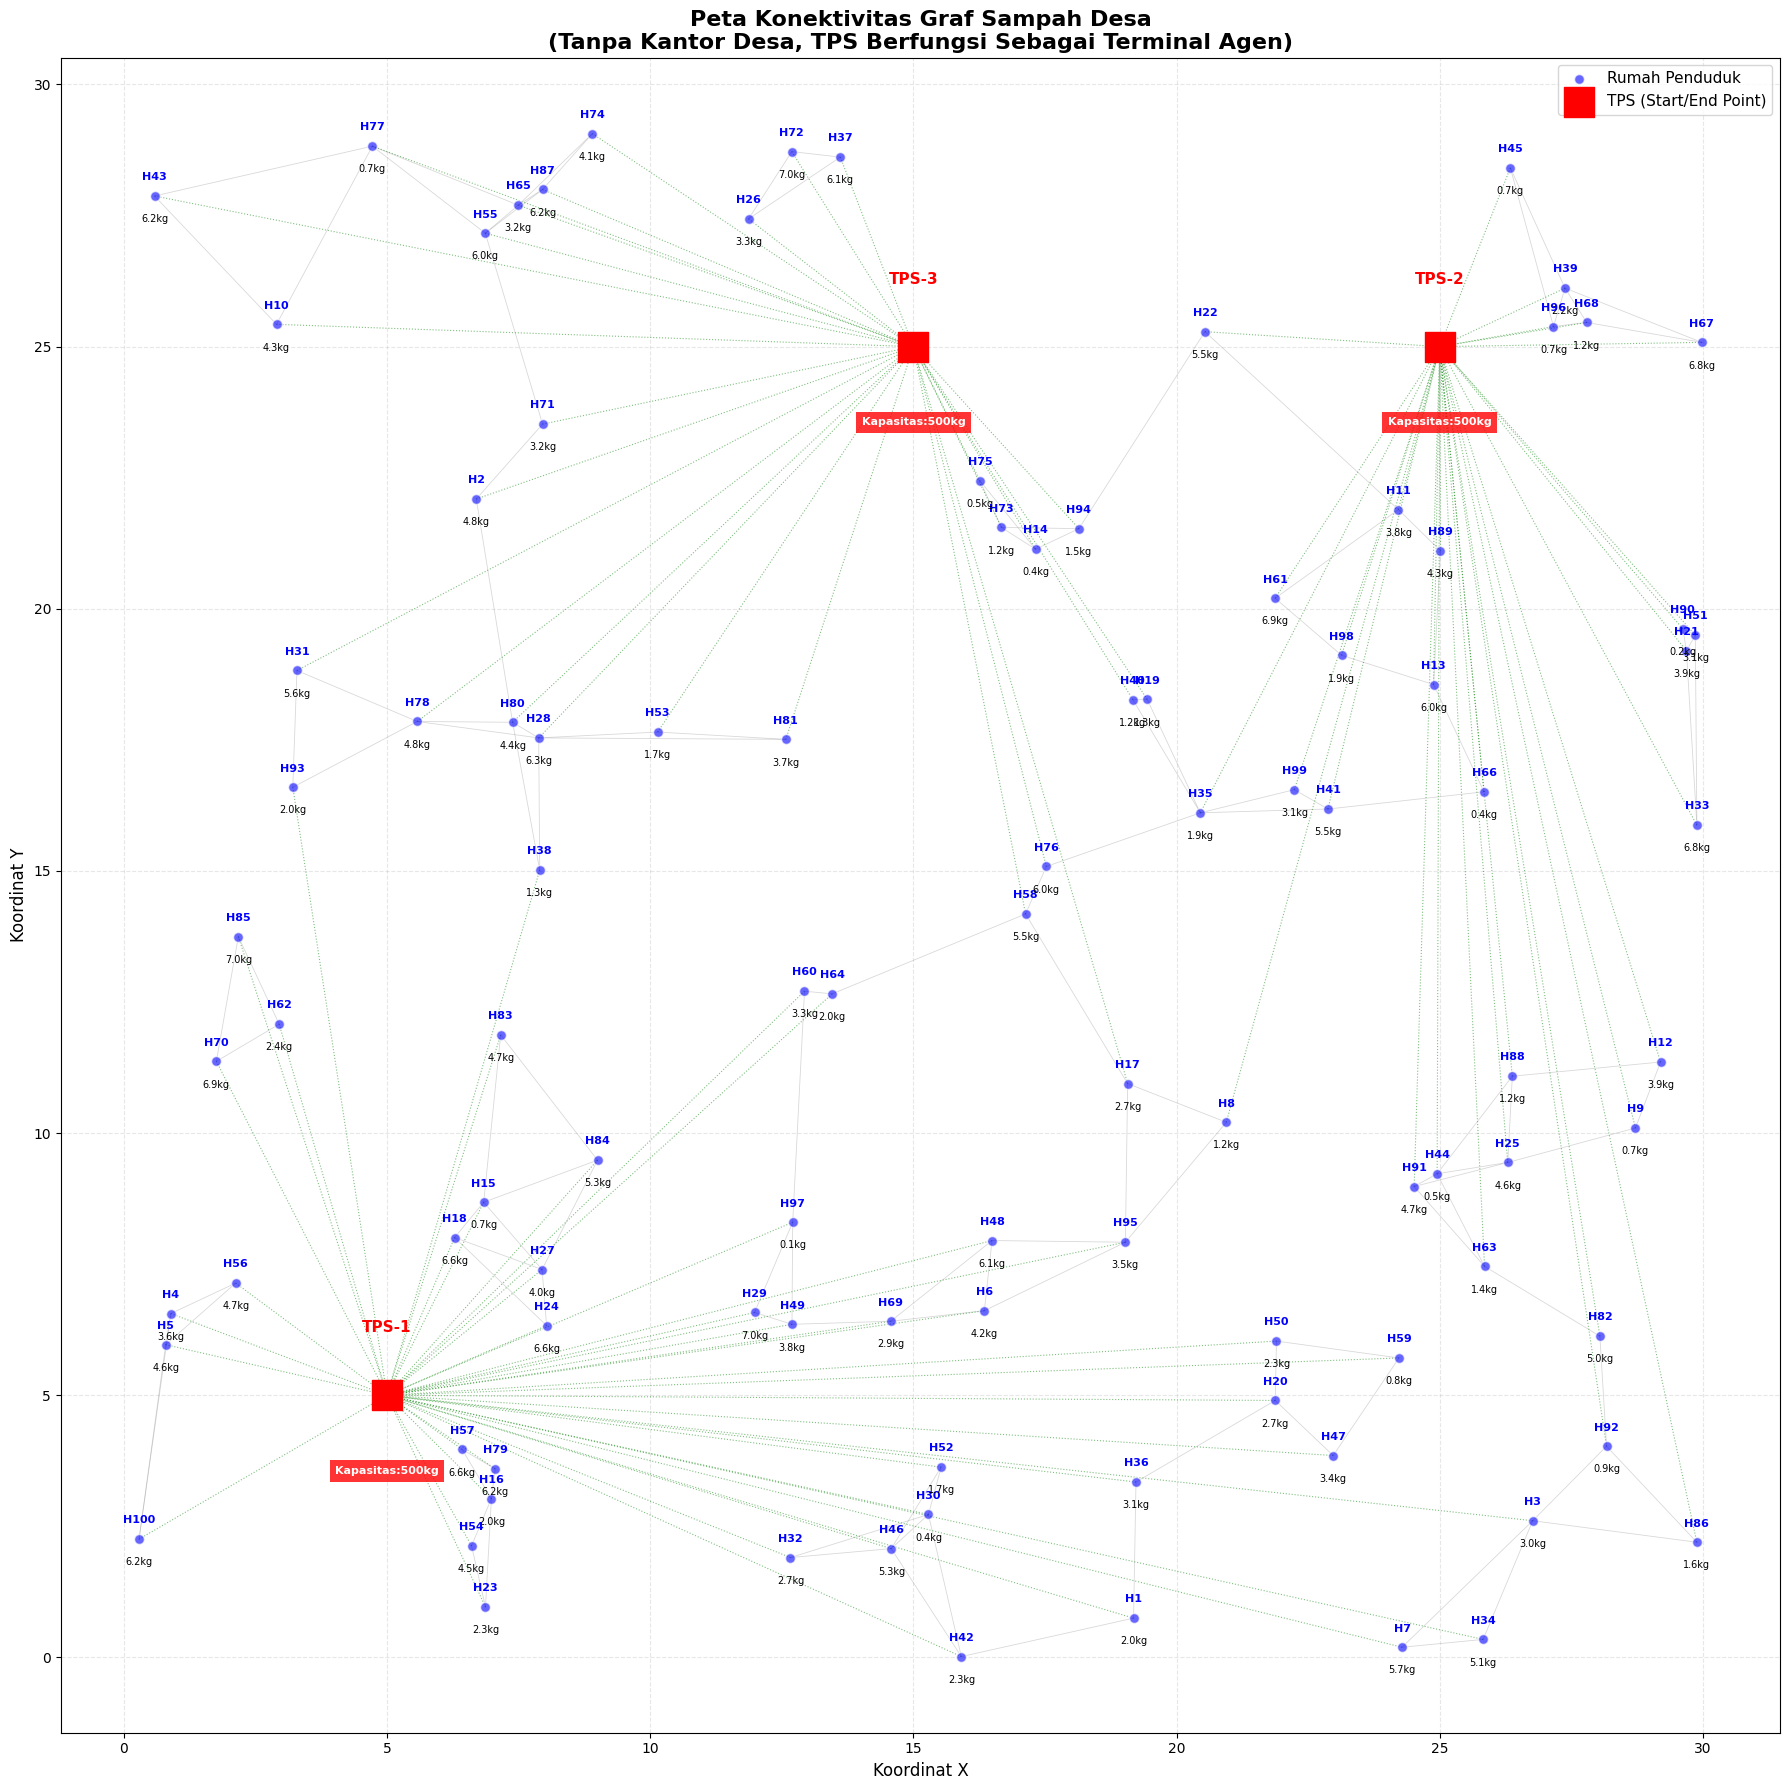

In [34]:
# ==========================================================
# 2. SELEKSI JALAN DAN VISUALISASI PETA
# ==========================================================
def plot_village_map(houses, tps_list):
    plt.figure(figsize=(18, 18))
    seen_edges = set()
    
    # Hubungkan setiap rumah ke 2 tetangga terdekatnya
    for start_node in houses:
        distances = []
        for end_node in houses:
            if start_node.id == end_node.id: continue
            distances.append((get_dist(start_node, end_node), end_node))
        distances.sort(key=lambda x: x[0])
        
        for i in range(min(2, len(distances))):
            d, end_node = distances[i]
            pair = tuple(sorted((start_node.id, end_node.id)))
            if pair not in seen_edges:
                plt.plot([start_node.x, end_node.x], [start_node.y, end_node.y], color='gray', linestyle='-', linewidth=0.6, alpha=0.3)
                seen_edges.add(pair)
                
    # Hubungkan setiap rumah ke TPS terdekat (memutus isolasi graf)
    for h in houses:
        closest_tps = min(tps_list, key=lambda t: get_dist(h, t))
        d = get_dist(h, closest_tps)
        pair = tuple(sorted((h.id, closest_tps.id)))
        if pair not in seen_edges:
            plt.plot([h.x, closest_tps.x], [h.y, closest_tps.y], color='green', linestyle=':', linewidth=0.8, alpha=0.5)
            seen_edges.add(pair)

    # Plot Rumah Penduduk
    plt.scatter([h.x for h in houses], [h.y for h in houses], c='blue', s=50, label='Rumah Penduduk', alpha=0.6, edgecolors='white', zorder=5)
    for h in houses:
        plt.text(h.x, h.y + 0.3, f"{h.id}", fontsize=8, color='blue', ha='center', fontweight='bold', zorder=6)
        plt.text(h.x, h.y - 0.5, f"{h.waste:.1f}kg", fontsize=7, color='black', ha='center', zorder=6)

    # Plot TPS (Kini Berfungsi Sebagai Depot Awal & Akhir)
    plt.scatter([t.x for t in tps_list], [t.y for t in tps_list], c='red', marker='s', s=450, label='TPS (Start/End Point)', zorder=10)
    for t in tps_list:
        plt.text(t.x, t.y + 1.2, f"{t.id}", fontsize=11, color='red', ha='center', fontweight='bold', zorder=11)
        plt.text(t.x, t.y - 1.5, f"Kapasitas:{t.cap:.0f}kg", fontsize=8, color='white', ha='center', fontweight='bold', bbox=dict(facecolor='red', alpha=0.8, edgecolor='none'))

    plt.title('Peta Konektivitas Graf Sampah Desa\n(Tanpa Kantor Desa, TPS Berfungsi Sebagai Terminal Agen)', fontsize=16, fontweight='bold')
    plt.xlabel('Koordinat X', fontsize=12)
    plt.ylabel('Koordinat Y', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()

print("Membuat peta interkoneksi...")
plot_village_map(houses, tps_list)

In [35]:
# ==========================================================
# 3. ALGORITMA GREEDY BEST-FIRST SEARCH (Dengan Pengecekan Kapasitas TPS & Rendezvous Rasional)
# ==========================================================
print("\nMengeksekusi simulasi rute pengangkutan...")

for v in all_vehicles:
    v.log.append([v.t, "Mulai Sif", f"Berangkat dari {v.home_tps.id}"])

while True:
    active_v = [v for v in all_vehicles if v.t < v.end_t]
    if not active_v: break
    active_v.sort(key=lambda v: v.t)
    v = active_v[0] 

    total_waste_left = sum(h.waste for h in houses if h.waste > 0.01)

    # KONDISI 1: Pengosongan Muatan (Greedy ke TPS yang muat ATAU Rendezvous Truk)
    if v.load >= v.cap * 0.9 or (total_waste_left < 0.1 and v.load > 0):
        
        # Pengecekan Kapasitas TPS
        all_tps_sorted = sorted(tps_list, key=lambda t: get_dist(v, t))
        target_node = None
        is_tps = True
        
        for t in all_tps_sorted:
            if t.cap - t.load >= v.load: # Cek apakah TPS ini masih muat
                target_node = t
                break
                
        if target_node is None:
            v.log.append([v.t, "Darurat", "Seluruh TPS di desa penuh kapasitas!"])
            v.t = v.end_t
            continue
            
        # Logging jika TPS terdekat ternyata penuh (Peralihan Rute)
        if target_node != all_tps_sorted[0]:
            v.log.append([v.t, "Rute Dialihkan", f"TPS terdekat ({all_tps_sorted[0].id}) PENUH. Beralih target ke {target_node.id}"])
        
        # Pengecekan Rendezvous (Khusus Gerobak, evaluasi jarak truk secara rasional)
        if v.vtype == "Gerobak":
            valid_trucks = [trk for trk in trucks if trk.t >= TIME_TRK_START and trk.t < trk.end_t and trk.cap - trk.load >= v.load]
            if valid_trucks:
                nearest_trk = min(valid_trucks, key=lambda trk: get_dist(v, trk))
                # Gerobak hanya titip jika jarak truk *benar-benar* lebih dekat dibanding jarak TPS target
                if get_dist(v, nearest_trk) < get_dist(v, target_node):
                    target_node = nearest_trk
                    is_tps = False
        
        d = get_dist(v, target_node)
        t_travel = d * v.speed
        dump_amt = v.load
        t_action = dump_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.t = v.end_t
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d
        v.x, v.y = target_node.x, target_node.y
        
        if is_tps:
            target_node.load += dump_amt
            v.log.append([v.t, "Setor Sampah", f"Menurunkan {dump_amt:.1f} kg sampah di {target_node.id}"])
        else:
            target_node.load += dump_amt
            v.log.append([v.t, "Rendezvous", f"Mentransfer {dump_amt:.1f} kg sampah ke {target_node.id}"])
            # Update log dan waktu truk yang dititipi
            target_node.log.append([max(v.t, target_node.t), "Terima Transfer", f"Menerima {dump_amt:.1f} kg dari {v.id}"])
            target_node.t = max(target_node.t, v.t)
            
        v.load = 0

    # KONDISI 2: Penjemputan Sampah ke Rumah (Greedy BFS)
    else:
        valid_houses = [h for h in houses if h.waste > 0.01]
        if not valid_houses:
            break
            
        target_h = min(valid_houses, key=lambda h: get_dist(v, h))
        d = get_dist(v, target_h)
        t_travel = d * v.speed
        pick_amt = min(v.cap - v.load, target_h.waste)
        t_action = pick_amt * v.load_time
        
        if v.t + t_travel + t_action > v.end_t:
            v.t = v.end_t
            continue
            
        v.t += t_travel + t_action
        v.dist_traveled += d
        v.x, v.y = target_h.x, target_h.y
        target_h.waste -= pick_amt
        v.load += pick_amt
        v.log.append([v.t, "Angkut Sampah", f"Mengambil {pick_amt:.1f} kg dari {target_h.id}"])

# SIF SELESAI: Kendaraan kembali ke TPS Markas masing-masing
for v in all_vehicles:
    d_return = get_dist(v, v.home_tps)
    t_return = d_return * v.speed
    v.dist_traveled += d_return
    v.t = min(v.end_t, v.t + t_return)
    v.log.append([v.t, "Selesai Sif", f"Kembali dan Parkir di {v.home_tps.id}. Sisa muatan gantung: {v.load:.1f} kg"])

print("Simulasi Selesai.")


Mengeksekusi simulasi rute pengangkutan...
Simulasi Selesai.


In [36]:
# ==========================================================
# 4. LAPORAN TRANSPARANSI
# ==========================================================
def format_time_log(min_from_zero):
    return f"{int(min_from_zero // 60):02d}:{int(min_from_zero % 60):02d}"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n" + "="*80)
print("             LAPORAN EVALUASI & TRANSPARANSI MANAJEMEN SAMPAH (PAK KADES)")
print("="*80)

# 1. TRANSPARANSI SISA SAMPAH DAN STATUS TPS
sisa_rumah = sum(h.waste for h in houses)
total_tps_collected = sum(t.load for t in tps_list)

print("\n[A] STATUS SAMPAH DAN TEMPAT PEMBUANGAN AKHIR (TPS)")
print("-" * 60)
print(f"Sisa Sampah di Area Perumahan Warga   : {sisa_rumah:.2f} kg")
print(f"Total Keseluruhan Sampah di Semua TPS : {total_tps_collected:.2f} kg\n")

print("Rincian Sampah Sukses Tertampung di Masing-Masing TPS:")
tps_summary = []
for t in tps_list:
    status_penuh = "Kritis/Penuh!" if t.load >= t.cap else "Aman"
    tps_summary.append({
        "Nama TPS": t.id,
        "Kapasitas Maksimal": f"{t.cap:.1f} kg",
        "Sampah Tertampung": f"{t.load:.1f} kg",
        "Kapasitas Tersisa": f"{(t.cap - t.load):.1f} kg",
        "Status": status_penuh
    })
display(pd.DataFrame(tps_summary))

# 2. RINGKASAN AGEN
print("\n[B] RINGKASAN KINERJA ARMADA (KEMBALI KE TPS MARKAS)")
print("-" * 60)
summary_list = []
for v in all_vehicles:
    summary_list.append({
        "ID Agen": v.id,
        "Markas": v.home_tps.id,
        "Total Jarak (Satuan)": f"{v.dist_traveled:.2f}",
        "Sampah Gantung": f"{v.load:.2f} kg",
        "Waktu Parkir": format_time_log(v.t)
    })
display(pd.DataFrame(summary_list))

# 3. MASTER LOG TRANSPARANSI (Semua Kejadian)
print("\n[C] LOG PERGERAKAN LENGKAP (TRANSPARANSI KEPUTUSAN AGEN & RENDEZVOUS)")
print("-" * 60)
raw_logs = []
for v in all_vehicles:
    for item in v.log:
        raw_logs.append({
            "Waktu Pas": item[0],
            "Waktu (Jam)": format_time_log(item[0]),
            "Nama Agen": v.id,
            "Jenis Tindakan": item[1],
            "Detail Kejadian": item[2]
        })

df_master_log = pd.DataFrame(raw_logs).sort_values(by="Waktu Pas")
df_master_log = df_master_log[["Waktu (Jam)", "Nama Agen", "Jenis Tindakan", "Detail Kejadian"]].reset_index(drop=True)
display(df_master_log)


             LAPORAN EVALUASI & TRANSPARANSI MANAJEMEN SAMPAH (PAK KADES)

[A] STATUS SAMPAH DAN TEMPAT PEMBUANGAN AKHIR (TPS)
------------------------------------------------------------
Sisa Sampah di Area Perumahan Warga   : 0.00 kg
Total Keseluruhan Sampah di Semua TPS : 344.61 kg

Rincian Sampah Sukses Tertampung di Masing-Masing TPS:


,Nama TPS,Kapasitas Maksimal,Sampah Tertampung,Kapasitas Tersisa,Status
0,TPS-1,500.0 kg,179.6 kg,320.4 kg,Aman
1,TPS-2,500.0 kg,159.0 kg,341.0 kg,Aman
2,TPS-3,500.0 kg,6.0 kg,494.0 kg,Aman



[B] RINGKASAN KINERJA ARMADA (KEMBALI KE TPS MARKAS)
------------------------------------------------------------


,ID Agen,Markas,Total Jarak (Satuan),Sampah Gantung,Waktu Parkir
0,Gerobak-1,TPS-1,36.58,0.00 kg,09:46
1,Gerobak-2,TPS-1,37.25,0.00 kg,09:19
2,Gerobak-3,TPS-1,42.48,0.00 kg,09:36
3,Gerobak-4,TPS-2,61.08,3.51 kg,10:10
4,Gerobak-5,TPS-2,42.45,0.00 kg,09:34
5,Gerobak-6,TPS-3,49.13,5.51 kg,09:38
6,Gerobak-7,TPS-3,44.50,0.00 kg,09:37
7,Truk-1,TPS-1,111.28,0.00 kg,09:30
8,Truk-2,TPS-1,109.58,0.00 kg,09:19
9,Truk-3,TPS-2,111.37,0.00 kg,09:25



[C] LOG PERGERAKAN LENGKAP (TRANSPARANSI KEPUTUSAN AGEN & RENDEZVOUS)
------------------------------------------------------------


,Waktu (Jam),Nama Agen,Jenis Tindakan,Detail Kejadian
0,06:00,Gerobak-1,Mulai Sif,Berangkat dari TPS-1
1,06:00,Gerobak-2,Mulai Sif,Berangkat dari TPS-1
2,06:00,Gerobak-3,Mulai Sif,Berangkat dari TPS-1
3,06:00,Gerobak-4,Mulai Sif,Berangkat dari TPS-2
4,06:00,Gerobak-5,Mulai Sif,Berangkat dari TPS-2
5,06:00,Gerobak-6,Mulai Sif,Berangkat dari TPS-3
6,06:00,Gerobak-7,Mulai Sif,Berangkat dari TPS-3
7,06:08,Gerobak-4,Angkut Sampah,Mengambil 0.7 kg dari H96
8,06:09,Gerobak-6,Angkut Sampah,Mengambil 0.5 kg dari H75
9,06:12,Gerobak-5,Angkut Sampah,Mengambil 2.2 kg dari H39
